<!-- config-banner -->
# DINO 1° — why 2× viscosity stabilises the forward and the adjoint, and what else does (2026-09-09)

**`viscRef` against `visc2x`, restarts from the 2× spin-up's year-170 and year-180 pickups**
(forward 2 yr and 10 yr, adjoint 30 d and 183 d), plus the kappa member M7's
own 5-yr adjoint 31046 restarted 183 d before its end. Runs and settings are
listed in `input/variants/stability_study/README.md` and
`input_tap/variants/stability_study/README.md`; this notebook reads their
monitor streams and `ADJ*` dumps and writes figures to
`DINO_1deg_outputs/analysis/stability_study/figures/` (several runs, so a
campaign directory, not a run directory).

Sections: 1 forward restarts (2 yr) — what the viscosity, its D/Z split, the
vorticity scheme, GM and the grid-Reynolds floor do to the flow; 2 the 10-yr
continuations; 3 adjoint growth over 30 d for every switch tried, GM included;
4 the M7 half-year adjoint: the original blow-up reproduced, and what scheme
30 and the Reynolds floor do to it; 5 conclusions.

In [1]:
import os, glob, re, collections, filecmp, warnings
import numpy as np
import matplotlib.pyplot as plt
import xmitgcm
warnings.filterwarnings("ignore")
RUNS = "/scratch2/tshahriar/DINO_1deg_outputs/runs"
FIG = "/scratch2/tshahriar/DINO_1deg_outputs/analysis/stability_study/figures"; os.makedirs(FIG, exist_ok=True)
SPIN = RUNS + "/forward/spinup_200yr_visc2x/DINO_1deg_frd_200yr_from_rest_visc2x_run30983"
IT170, IT180, SPD, SPY = 2986560, 3162240, 48, 17568

def find(pattern):
    hits = sorted(glob.glob(f"{RUNS}/{pattern}") + glob.glob(f"{RUNS}/*/{pattern}") + glob.glob(f"{RUNS}/*/*/{pattern}"))
    assert hits, pattern
    return hits[-1]

def mon(stdout):
    b, cur = collections.OrderedDict(), None
    for l in open(stdout):
        if "%MON" not in l: continue
        s = l.split("%MON", 1)[1].strip()
        if s.startswith("time_tsnumber"):
            cur = int(s.split("=")[1]); b[cur] = {}
        elif cur is not None and "=" in s:
            k, v = s.split("=", 1)
            try: b[cur][k.strip()] = float(v)
            except ValueError: pass
    return b

def series(b, key, it0=IT170, lo=None, hi=None):
    its = np.array([i for i in b if (lo is None or i >= lo) and (hi is None or i <= hi)])
    return (its - it0) / SPY, np.array([b[i].get(key, np.nan) for i in its])

def speed_series(b, **kw):
    yr, umax = series(b, "dynstat_uvel_max", **kw); _, umin = series(b, "dynstat_uvel_min", **kw)
    _, vmax = series(b, "dynstat_vvel_max", **kw); _, vmin = series(b, "dynstat_vvel_min", **kw)
    _, ke = series(b, "ke_max", **kw); _, kem = series(b, "ke_mean", **kw)
    return yr, np.maximum(umax, -umin), np.maximum(vmax, -vmin), ke, kem

## 1. Forward restarts, 2 yr from year 170

Peak speeds and kinetic energy from the monitor stream (every 5 d), each run
against the spin-up's own years 170–172 (monthly monitor). The tags are the
`stability_study` variants; `viscRef` is DINO's reference viscosity on both the
divergence (D) and vorticity (Z) parts, `viscDref_Z2x` doubles only Z.

tag                     |u|max  |v|max  ke_max  ke_mean   (values at 2 yr)
spin-up 2x                0.59    0.76    0.28     2.94e-4
viscRef                   0.76    1.02    0.53     3.51e-4
viscRef_vort3             0.72    1.02    0.51     3.50e-4
viscRef_vort2             0.67    1.01    0.51     3.50e-4
viscRef_cori1             0.75    0.93    0.42     3.15e-4
viscRef_A4Grid1p0e-2      0.70    0.98    0.50     3.42e-4
viscRef_gmOff             0.85    1.07    0.57     3.73e-4
visc2x_gmOff              0.59    0.79    0.31     3.13e-4
viscD2x_Zref              0.73    1.00    0.51     3.50e-4
viscDref_Z2x              0.58    0.76    0.29     2.95e-4
viscRef_ReMax2            0.51    0.78    0.31     3.45e-4


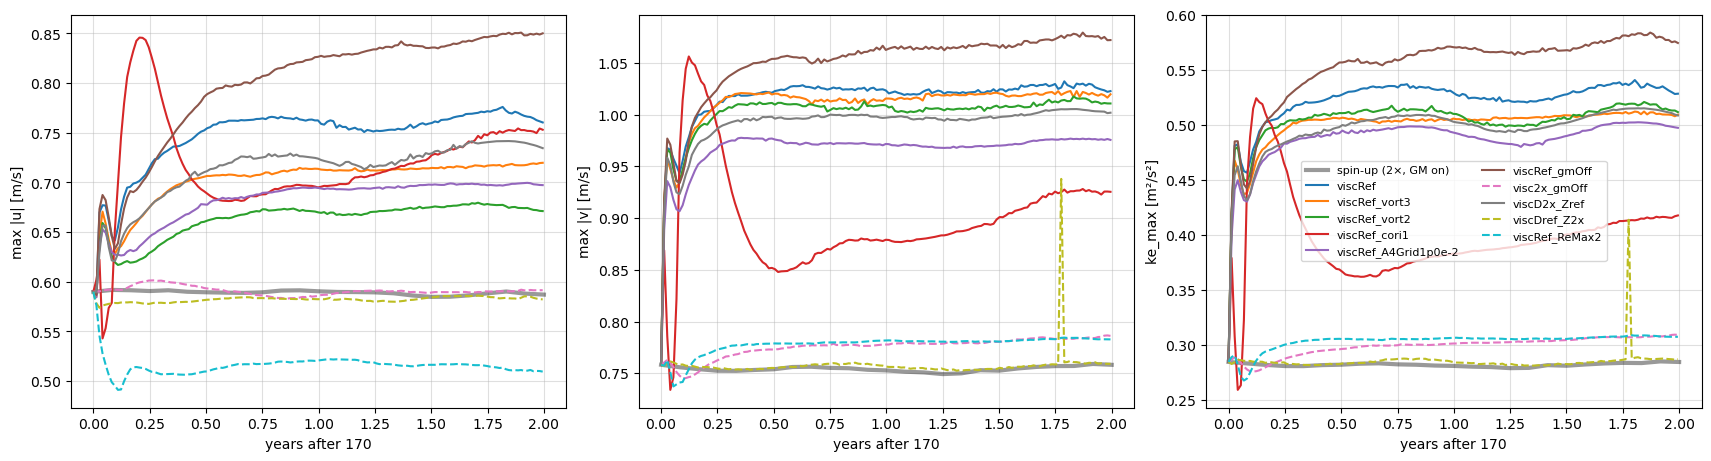

In [2]:
tags = ["viscRef", "viscRef_vort3", "viscRef_vort2", "viscRef_cori1", "viscRef_A4Grid1p0e-2",
        "viscRef_gmOff", "visc2x_gmOff", "viscD2x_Zref", "viscDref_Z2x", "viscRef_ReMax2"]
fwd = {t: mon(find(f"DINO_1deg_frd_2yr_from170yrPk_{t}_run*") + "/STDOUT.0000") for t in tags}
spin = mon(SPIN + "/STDOUT.0000")
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
yr, u, v, ke, kem = speed_series(spin, lo=IT170, hi=IT170 + 2 * SPY)
for a, s, lab in zip(ax, (u, v, ke), ("max |u| [m/s]", "max |v| [m/s]", "ke_max [m²/s²]")):
    a.plot(yr, s, "k", lw=3, alpha=0.4, label="spin-up (2×, GM on)"); a.set_ylabel(lab); a.set_xlabel("years after 170"); a.grid(alpha=0.4)
print(f"{'tag':22s} {'|u|max':>7s} {'|v|max':>7s} {'ke_max':>7s} {'ke_mean':>8s}   (values at 2 yr)")
print(f"{'spin-up 2x':22s} {u[-1]:7.2f} {v[-1]:7.2f} {ke[-1]:7.2f} {kem[-1]*1e4:8.2f}e-4")
for t, b in fwd.items():
    yr, u, v, ke, kem = speed_series(b)
    ls = "--" if t in ("viscDref_Z2x", "viscRef_ReMax2", "visc2x_gmOff") else "-"
    for a, s in zip(ax, (u, v, ke)): a.plot(yr, s, ls, lw=1.5, label=t)
    print(f"{t:22s} {u[-1]:7.2f} {v[-1]:7.2f} {ke[-1]:7.2f} {kem[-1]*1e4:8.2f}e-4")
ax[2].legend(fontsize=8, ncol=2)
fig.savefig(FIG + "/forward_2yr_restarts_speeds.png", dpi=120); plt.show()

### Where `viscAhReMax=2.` adds viscosity

`viscAhReMax` is a floor, A ≥ |u|·L/Re_max, so it leaves DINO's field alone
where the flow is slower than 0.27 m/s (Re_Δ = 2 at that speed for DINO's
A = 0.27·Δx/2) and raises it only in the jets. The last monthly `VISCAHZ` of
the 2-yr run against the reference field 0.135·dxC.

VISCAHZ / reference: max 2.49; wet fraction > 1.05: 0.0078, > 1.5: 0.0016, > 2: 0.0003


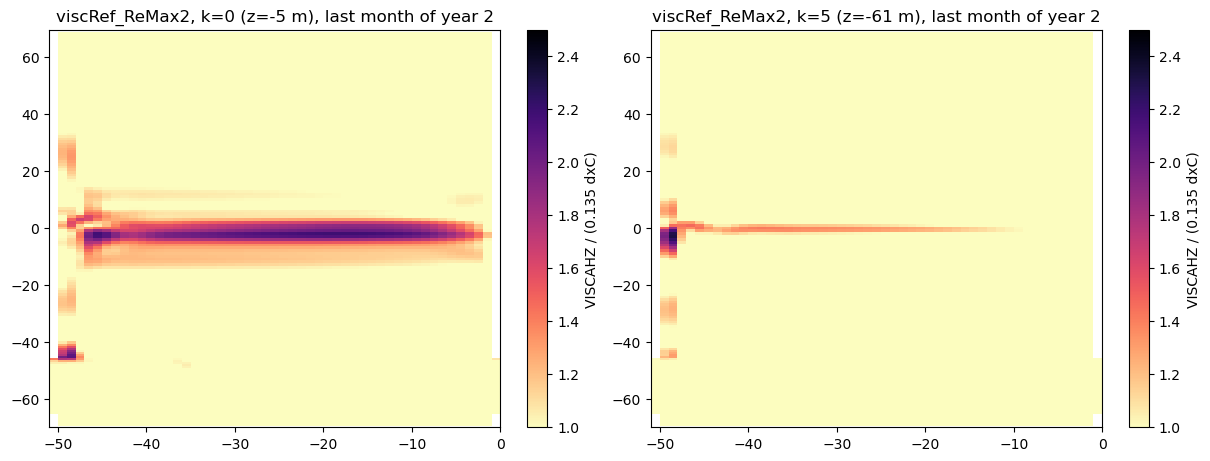

In [3]:
r = find("DINO_1deg_frd_2yr_from170yrPk_viscRef_ReMax2_run*")
its = sorted(int(p.split(".")[-2]) for p in glob.glob(r + "/viscDiag.*.meta"))
ds = xmitgcm.open_mdsdataset(r, grid_dir=r, prefix=["viscDiag"], geometry="curvilinear", iters=[its[-1]], delta_t=1800.)
wet = (ds.hFacC > 0).values                                   # VISCAHZ sits on the vorticity grid, dxC on the cell grid: same shape, compare as arrays
rv = np.where(wet, ds.VISCAHZ.isel(time=0).values / (0.135 * ds.dxC.values)[None], np.nan)
print(f"VISCAHZ / reference: max {np.nanmax(rv):.2f}; wet fraction > 1.05: {(rv[wet] > 1.05).mean():.4f}, > 1.5: {(rv[wet] > 1.5).mean():.4f}, > 2: {(rv[wet] > 2).mean():.4f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for a, k in zip(ax, (0, 5)):
    im = a.pcolormesh(ds.XC.values, ds.YC.values, rv[k], vmin=1, vmax=2.5, cmap="magma_r", shading="auto"); fig.colorbar(im, ax=a, label="VISCAHZ / (0.135 dxC)")
    a.set_title(f"viscRef_ReMax2, k={k} (z={float(ds.Z[k]):.0f} m), last month of year 2")
fig.savefig(FIG + "/ReMax2_viscosity_ratio_maps.png", dpi=120); plt.show()

## 2. The 10-yr continuations

`viscRef` and `viscRef_ReMax2` for 10 yr from year 170, monthly monitor,
against the spin-up's years 170–180.

viscRef: 121 monitor blocks, last year 10.00, ended=True; max |u| 0.78, max |v| 1.03, ke_max 0.54
viscRef_ReMax2: 121 monitor blocks, last year 10.00, ended=True; max |u| 0.59, max |v| 0.85, ke_max 0.31


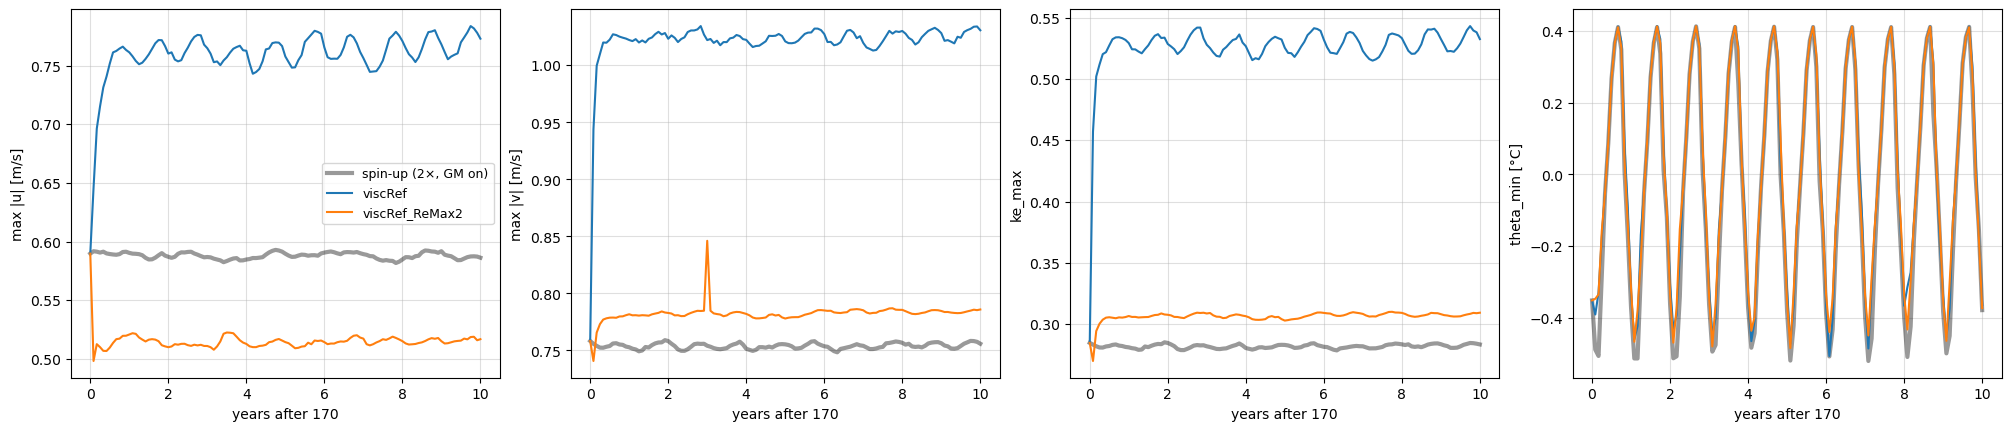

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.2), constrained_layout=True)
yr, u, v, ke, kem = speed_series(spin, lo=IT170, hi=IT170 + 10 * SPY)
_, th = series(spin, "dynstat_theta_min", lo=IT170, hi=IT170 + 10 * SPY)
for a, s, lab in zip(ax, (u, v, ke, th), ("max |u| [m/s]", "max |v| [m/s]", "ke_max", "theta_min [°C]")):
    a.plot(yr, s, "k", lw=3, alpha=0.4, label="spin-up (2×, GM on)"); a.set_ylabel(lab); a.set_xlabel("years after 170"); a.grid(alpha=0.4)
for t in ("viscRef", "viscRef_ReMax2"):
    g = glob.glob(f"{RUNS}/forward/DINO_1deg_frd_10yr_from170yrPk_{t}_run*") + glob.glob(f"{RUNS}/forward/*/DINO_1deg_frd_10yr_from170yrPk_{t}_run*")
    if not g: print(t, "10-yr run not found"); continue
    b = mon(g[0] + "/STDOUT.0000"); yr, u, v, ke, kem = speed_series(b); _, th = series(b, "dynstat_theta_min")
    ended = "Run ended" in open(g[0] + "/run_timing.txt").read()
    print(f"{t}: {len(yr)} monitor blocks, last year {yr[-1]:.2f}, ended={ended}; max |u| {u.max():.2f}, max |v| {v.max():.2f}, ke_max {ke.max():.2f}")
    for a, s in zip(ax, (u, v, ke, th)): a.plot(yr, s, lw=1.5, label=t)
ax[0].legend(fontsize=9)
fig.savefig(FIG + "/forward_10yr_continuations.png", dpi=120); plt.show()

## 3. Adjoint growth over 30 d, from the 180-yr pickup

Wet-RMS of `ADJtheta` per 5-d dump against lead time, one curve per switch.
There is no adjoint monitor stream in these builds, so the dumps are the
record. The reference adjoint (2×, GM off) is 31140.

visc2x, GM off (31140)     rms(ADJtheta) at lead 5/15/25 d: 4.03e-04  3.31e-04  2.34e-04
viscRef                    rms(ADJtheta) at lead 5/15/25 d: 3.88e-04  3.19e-04  2.26e-04
viscRef_vort3              rms(ADJtheta) at lead 5/15/25 d: 3.87e-04  3.18e-04  2.25e-04
viscRef_ReMax2             rms(ADJtheta) at lead 5/15/25 d: 3.88e-04  3.19e-04  2.26e-04
visc2x_gmOn                rms(ADJtheta) at lead 5/15/25 d: 6.44e-04  3.06e-04  2.26e-04
viscRef_gmOn               rms(ADJtheta) at lead 5/15/25 d: 1.13e+04  3.98e-03  2.17e-04
visc2x_gmFwd               rms(ADJtheta) at lead 5/15/25 d: 2.16e+23  1.45e+11  2.35e-04
viscRef_gmFwd              rms(ADJtheta) at lead 5/15/25 d: 2.49e+25  2.91e+10  2.26e-04
visc2x_approxAdv           rms(ADJtheta) at lead 5/15/25 d: 4.03e-04  3.31e-04  2.34e-04
viscRef_approxAdv          rms(ADJtheta) at lead 5/15/25 d: 3.88e-04  3.19e-04  2.26e-04


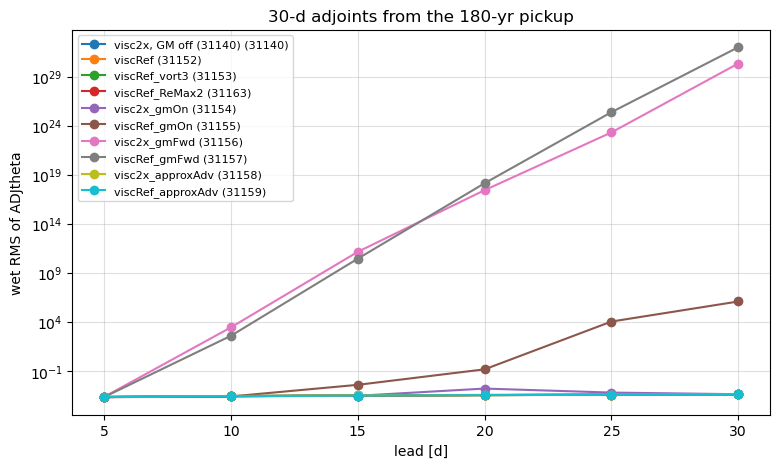

In [5]:
def adj_curve(d, var="ADJtheta"):
    fs = sorted(glob.glob(f"{d}/{var}.*.data"))
    its = np.array([int(os.path.basename(f).split(".")[1]) for f in fs])
    lead = (its.max() + 5 * SPD - its) / SPD          # the first dump is written 5 d (adjDumpFreq) before the end of the window
    rms = np.array([np.sqrt(np.mean(np.fromfile(f, dtype=">f4").astype("f8") ** 2)) for f in fs])
    return lead, rms
adj30 = collections.OrderedDict()
adj30["visc2x, GM off (31140)"] = find("DINO_1deg_tapAdj_nocheckpoint_30d_from180yrPk_visc2x_run31140")
for tag in ("viscRef", "viscRef_vort3", "viscRef_ReMax2", "visc2x_gmOn", "viscRef_gmOn", "visc2x_gmFwd", "viscRef_gmFwd", "visc2x_approxAdv", "viscRef_approxAdv"):
    g = glob.glob(f"{RUNS}/adjoint/DINO_1deg_tapAdj_*_30d_from180yrPk_{tag}_run*") + glob.glob(f"{RUNS}/adjoint/*/DINO_1deg_tapAdj_*_30d_from180yrPk_{tag}_run*")
    if g: adj30[tag] = sorted(g)[-1]
fig, ax = plt.subplots(figsize=(9, 5))
for lab, d in adj30.items():
    lead, rms = adj_curve(d)
    ax.semilogy(lead, rms, "o-", label=f"{lab} ({os.path.basename(d).split('_run')[-1]})")
    print(f"{lab:26s} rms(ADJtheta) at lead 5/15/25 d: " + "  ".join(f"{r:.2e}" for l, r in zip(lead, rms) if int(l) in (5, 15, 25)))
ax.set_xlabel("lead [d]"); ax.set_ylabel("wet RMS of ADJtheta"); ax.grid(alpha=0.4); ax.legend(fontsize=8)
ax.set_title("30-d adjoints from the 180-yr pickup")
fig.savefig(FIG + "/adjoint_30d_growth_switches.png", dpi=120); plt.show()

## 4. The M7 half-year adjoint: the blow-up reproduced, and two candidate cures

Kappa member M7 (32× κ_v, 2× viscosity, GM off) blew up 132 d before the end of
its 5-yr adjoint 31046. Its namelist restarted from the monthly pickup that run
wrote 183 d before its end integrates the same trajectory and the same
terminal-30-d cost, so its 183-d adjoint is the last 183 d of 31046 — checked
byte for byte below for the control — and the same run with scheme 30 (DST3
without the flux limiter, both sweeps) or with `viscAhReMax=2.` shows what each
does to the blow-up.

control (scheme 33, 2×)   : 36 dumps, 36 byte-identical to 31046, all finite: True; rms at lead 180/150/90/30 d: 7.51e-03  1.69e-02  1.20e-04  2.52e-04
scheme 30 both sweeps     : 36 dumps, 0 byte-identical to 31046, all finite: True; rms at lead 180/150/90/30 d: 8.27e-05  9.10e-05  1.17e-04  2.50e-04
+ viscAhReMax=2           : 36 dumps, 0 byte-identical to 31046, all finite: True; rms at lead 180/150/90/30 d: 3.29e-03  7.29e-03  1.20e-04  2.52e-04


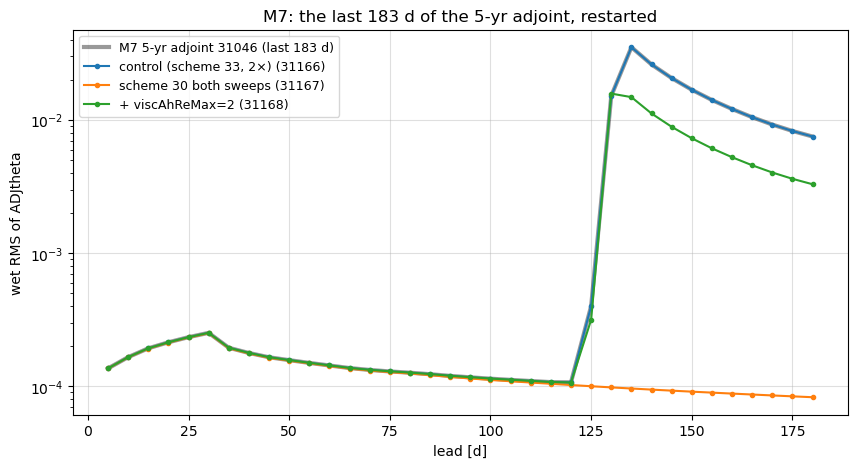

In [6]:
ref46 = find("DINO_1deg_tapAdj_ckpAll_5yr_M7_run31046")
m7 = collections.OrderedDict()
for tag, lab in (("M7_lastHalfYr", "control (scheme 33, 2×)"), ("M7_lastHalfYr_adv30", "scheme 30 both sweeps"), ("M7_lastHalfYr_ReMax2", "+ viscAhReMax=2")):
    g = glob.glob(f"{RUNS}/adjoint/DINO_1deg_tapAdj_ckpAll_183d_{tag}_run*") + glob.glob(f"{RUNS}/adjoint/*/DINO_1deg_tapAdj_ckpAll_183d_{tag}_run*")
    if g: m7[lab] = sorted(g)[-1]
lead46, rms46 = adj_curve(ref46); sel = lead46 <= 183
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(lead46[sel], rms46[sel], "k", lw=3, alpha=0.4, label="M7 5-yr adjoint 31046 (last 183 d)")
for lab, d in m7.items():
    lead, rms = adj_curve(d); ax.semilogy(lead, rms, "o-", ms=3, label=f"{lab} ({os.path.basename(d).split('_run')[-1]})")
    same = sum(filecmp.cmp(f, ref46 + "/" + os.path.basename(f), shallow=False) for f in glob.glob(d + "/ADJtheta.*.data") if os.path.exists(ref46 + "/" + os.path.basename(f)))
    fin = all(np.isfinite(np.fromfile(f, dtype=">f4")).all() for f in glob.glob(d + "/ADJtheta.*.data"))
    print(f"{lab:26s}: {len(lead)} dumps, {same} byte-identical to 31046, all finite: {fin}; rms at lead 180/150/90/30 d: " + "  ".join(f"{r:.2e}" for l, r in zip(lead, rms) if int(round(l)) in (30, 90, 150, 180)))
ax.set_xlabel("lead [d]"); ax.set_ylabel("wet RMS of ADJtheta"); ax.grid(alpha=0.4); ax.legend(fontsize=9)
ax.set_title("M7: the last 183 d of the 5-yr adjoint, restarted")
fig.savefig(FIG + "/M7_halfyear_adjoint_blowup_and_cures.png", dpi=120); plt.show()

## 5. Conclusions

- **Why 2× helps the forward.** Doubling DINO's viscosity acts entirely through
  its vorticity part: it holds the equatorial and channel boundary currents at
  0.76–0.79 m/s instead of the 1.0–1.1 m/s they reach at the reference
  viscosity (grid Reynolds numbers 3 instead of 5–8). The divergence part, the
  vorticity scheme (including DINO's own EEN), the Coriolis treatment and a
  biharmonic add-on do almost nothing. From a mature state the reference
  viscosity is stable for at least 10 yr (peaks flat, roughness flat, mean KE
  +3 % per decade), so the crash after ~180 yr from rest is a slow loss of
  margin, not a fast instability, and cannot be reproduced cheaply.
- **The smallest DINO-consistent forward change is `viscAhReMax=2.`**: DINO's
  closure is a grid-Reynolds-number closure (Re_Δ = 2 at |u| = 0.27 m/s);
  applying it with the local speed keeps DINO's field on more than 99 % of the
  domain, raises it only in the jets, and holds the peaks at the 2× level for
  the full 10 yr, with a finite 30-d adjoint of unchanged growth.
- **Why 2× only delays the adjoint.** The adjoint's blow-ups are the adjoint of
  the DST3 flux limiter (scheme 33): restarting the last 183 d of kappa member
  M7's blown 5-yr adjoint reproduces the run byte for byte, blow-up included;
  the same restart with the unlimited DST3 (scheme 30, both sweeps) has no
  blow-up at all, at a 0.45 % change of the forward cost. Viscosity (2×, the
  Reynolds floor) damps the burst but does not remove it; the kappa members
  that blew up were all 2× runs. The stock adjoint-only switch is inert in the
  Tapenade build (a TAF-only macro in `gad_advection.F`).
- **GM/Redi** is on in the forward spin-up and off in every adjoint; switching
  it on in the adjoint explodes within 20 d at the reference viscosity, is
  marginal at 2×, and the forward-sweep-only hybrid is catastrophic. The GM-free
  adjoint is the only stable configuration, and the mismatch with the forward
  is a known approximation from now on.